# make time series from casim data

In [ ]:
import xarray as xr 
import pandas as pd
import numpy as np 
from glob import glob 
import matplotlib.pyplot as plt 
from scipy.special import gamma, gammainc
import re
import xesmf as xe


import sys
# needed so I can call the functions from another folder.
sys.path.append('/home/users/esree/shes_a_model/model_functions/')
# loads of homemade functions <3 <3
from casim_boring_functions import open_declan_nc, make_variable, slice_to_domain


In [2]:
a_date = '20220730'
a_experiment = 'expt1'

new_combined = open_declan_nc(a_date, a_experiment)
sliced_domain = slice_to_domain(new_combined)

## make new units for some hydrometeors
new_hydro_list = ['graupel', 'cloud', 'ice', 'snow', 'rain']
for hydro in new_hydro_list:
    sliced_domain = make_variable(sliced_domain, hydro)

for hydro in new_hydro_list:
    sliced_domain = make_variable(sliced_domain, hydro, 'mass')

In [3]:
## original code - just getting irrespective mean / max of whole domain
domain_max = sliced_domain.max(dim=["grid_latitude", "grid_longitude", "model_level_number"])
domain_mean = sliced_domain.mean(dim=["grid_latitude", "grid_longitude", "model_level_number"])

# creating a mask to hide non cloud values - adding up all hydrometeors -> total cloud mass
# (!! i have not included rain - not sure if to do this??)
total_cloud_mass = sliced_domain['graupel_mass_m3'] + sliced_domain['cloud_mass_m3'] + sliced_domain['ice_mass_m3'] + sliced_domain['snow_mass_m3']
#total_cloud_mass_values = total_cloud_mass.values.flatten().ravel() # - can use this to visualise all the values
#non_zero_cloud_mask = total_cloud_mass_values > 0
#non_zero_values = total_cloud_mass_values[non_zero_cloud_mask]

# would also be possible to have minimum threshold
cloudy_cells = total_cloud_mass > 0
cloudy_domain = sliced_domain.where(cloudy_cells)

cloudy_max = cloudy_domain.max(dim=["grid_latitude", "grid_longitude", "model_level_number"])
cloudy_mean = cloudy_domain.mean(dim=["grid_latitude", "grid_longitude", "model_level_number"])


In [ ]:
#w_all = sliced_domain['upward_air_velocity'].values.flatten().ravel()
#w_all_non_nan = w_all[~np.isnan(w_all)]


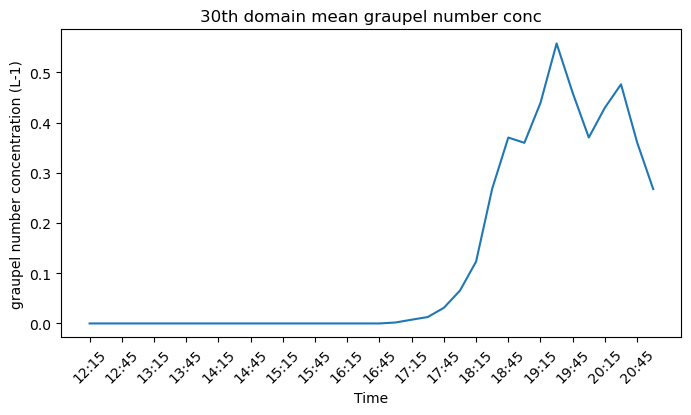

In [6]:
just_time = [str(t)[11:16] for t in cloudy_mean['time'].values]

fig, ax = plt.subplots(figsize=(8,4))

ax.plot(just_time, cloudy_mean['graupel_number_L'].values)
ax.set_xticks(ax.get_xticks()[::2])   # keep every 2nd tick
ax.set_xticklabels(just_time[::2], rotation=45)
ax.set_title('30th domain mean graupel number conc')
ax.set_ylabel("graupel number concentration (L-1)")
ax.set_xlabel("Time")
plt.show()

#### segregate by updraft?

In [12]:
#all_w_values = cloudy_domain['upward_air_velocity'].values.flatten().ravel()
w_min_threshold = 0
w_max_threshold = 2

#w_mask = (cloudy_domain['upward_air_velocity'] >= w_min_threshold) & (cloudy_domain['upward_air_velocity'] <= w_max_threshold)
w_mask = (cloudy_domain['upward_air_velocity'] >= w_min_threshold)
w_masked = cloudy_domain.where(w_mask)

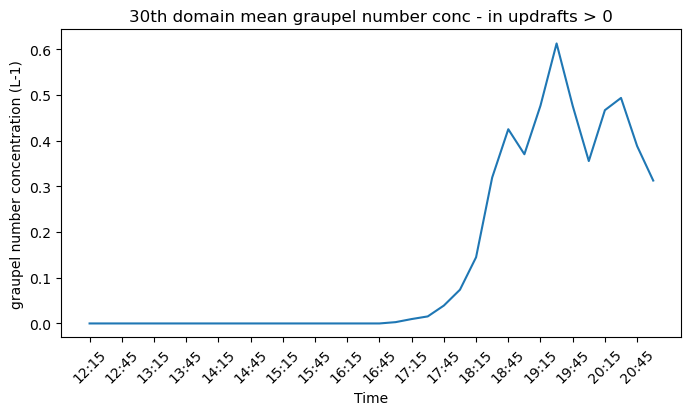

In [14]:
# idk if we did mean of where updraft is above 0?
cloudy_mean_w0 = w_masked.mean(dim=["grid_latitude", "grid_longitude", "model_level_number"])


just_time = [str(t)[11:16] for t in cloudy_mean_w0['time'].values]

fig, ax = plt.subplots(figsize=(8,4))

ax.plot(just_time, cloudy_mean_w0['graupel_number_L'].values)
ax.set_xticks(ax.get_xticks()[::2])   # keep every 2nd tick
ax.set_xticklabels(just_time[::2], rotation=45)
ax.set_title('30th domain mean graupel number conc - in updrafts > 0')
ax.set_ylabel("graupel number concentration (L-1)")
ax.set_xlabel("Time")
plt.show()